# Logistic Regression Project: Titanic Survival Prediction
**Dataset:** Titanic - Machine Learning from Disaster (Kaggle), file: `train.csv`  
**Objective:** Predict `Survived` (0 = Did not survive, 1 = Survived).  
**Model:** Median imputation + StandardScaler + balanced Logistic Regression.  
**Workflow:** load CSV → inspect data → EDA → treat missing values and outliers → train-test split → median imputation → scaling → train Logistic Regression → evaluate → interpret coefficients.

**Student:** ____________________  **Date:** ____________

## 1. Import libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')

## 2. Load the data

In [2]:
# Reads train.csv from the working folder; falls back to a file upload when run on Google Colab
import os
if os.path.exists('train.csv'):
    csv_file = 'train.csv'
else:
    from google.colab import files
    uploaded = files.upload()
    csv_file = next(iter(uploaded))

df = pd.read_csv(csv_file)
print('Shape:', df.shape)
df.head()

Shape: (891, 12)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## 3. Inspect the data

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [4]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [5]:
# Missing values per column
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [6]:
# Duplicate rows
df.duplicated().sum()

np.int64(0)

**Observations:** `Age` has missing values (about 20%), `Cabin` is missing for most passengers (about 77%) and `Embarked` is missing for 2 rows. There are no duplicate rows.

## 4. Exploratory Data Analysis

### 4.1 Univariate analysis

In [7]:
print(df['Survived'].value_counts(normalize=True) * 100)

Survived
0    61.616162
1    38.383838
Name: proportion, dtype: float64


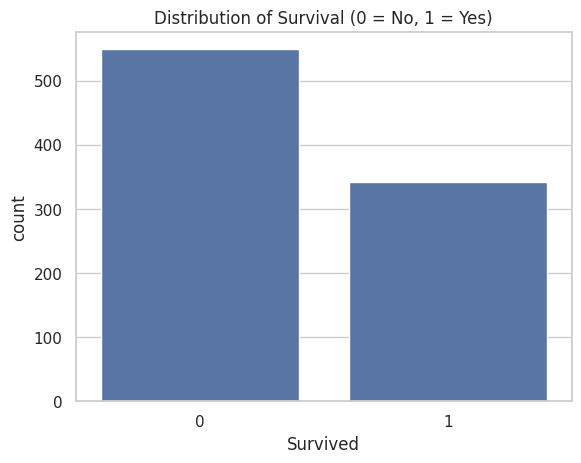

In [8]:
sns.countplot(data=df, x='Survived')
plt.title('Distribution of Survival (0 = No, 1 = Yes)')
plt.show()

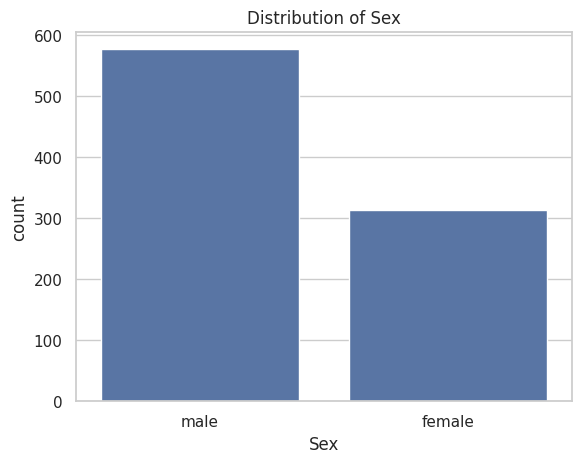

In [9]:
sns.countplot(data=df, x='Sex')
plt.title('Distribution of Sex')
plt.show()

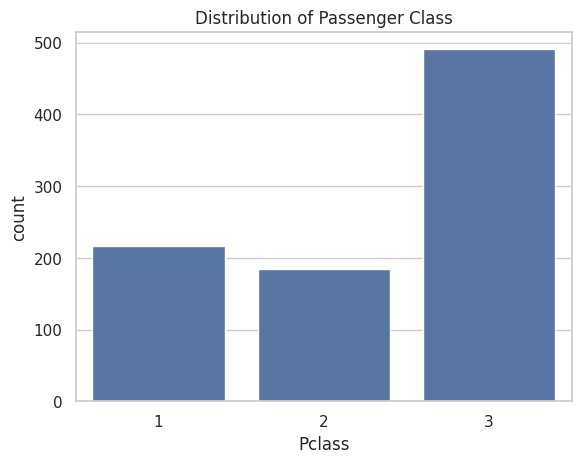

In [10]:
sns.countplot(data=df, x='Pclass')
plt.title('Distribution of Passenger Class')
plt.show()

### 4.2 Bivariate analysis

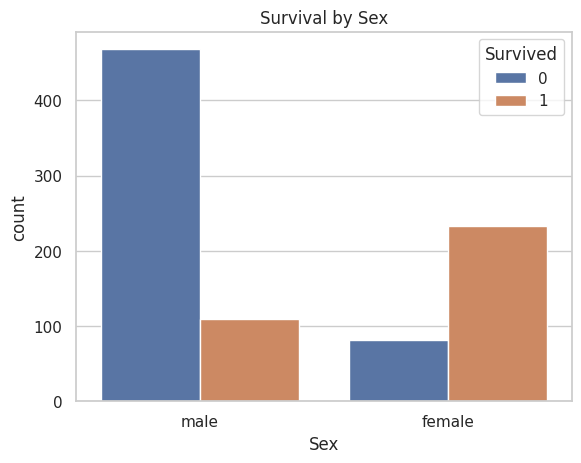

Sex
female    0.742
male      0.189
Name: Survived, dtype: float64


In [11]:
sns.countplot(data=df, x='Sex', hue='Survived')
plt.title('Survival by Sex')
plt.show()
print(df.groupby('Sex')['Survived'].mean().round(3))

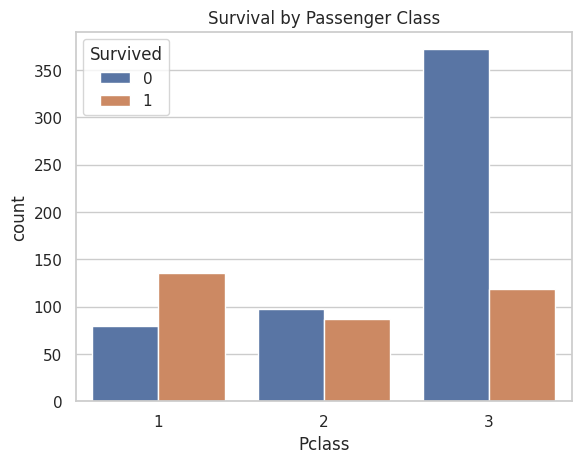

Pclass
1    0.630
2    0.473
3    0.242
Name: Survived, dtype: float64


In [12]:
sns.countplot(data=df, x='Pclass', hue='Survived')
plt.title('Survival by Passenger Class')
plt.show()
print(df.groupby('Pclass')['Survived'].mean().round(3))

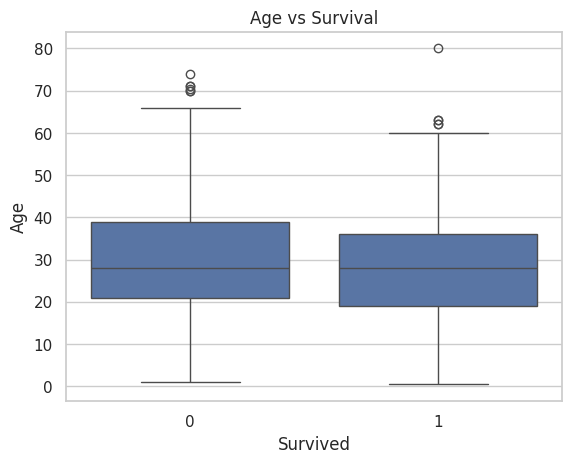

In [13]:
sns.boxplot(data=df, x='Survived', y='Age')
plt.title('Age vs Survival')
plt.show()

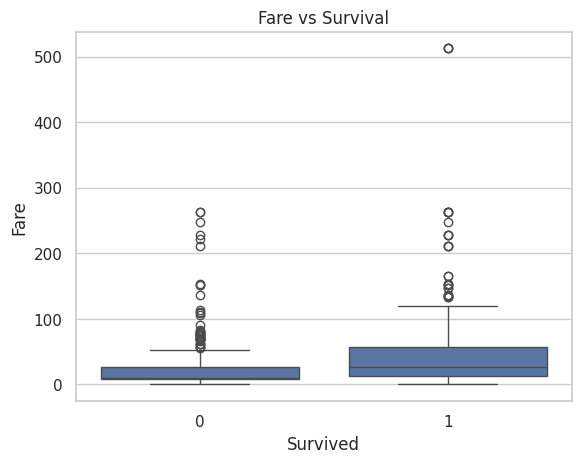

In [14]:
sns.boxplot(data=df, x='Survived', y='Fare')
plt.title('Fare vs Survival')
plt.show()

### 4.3 Multivariate analysis

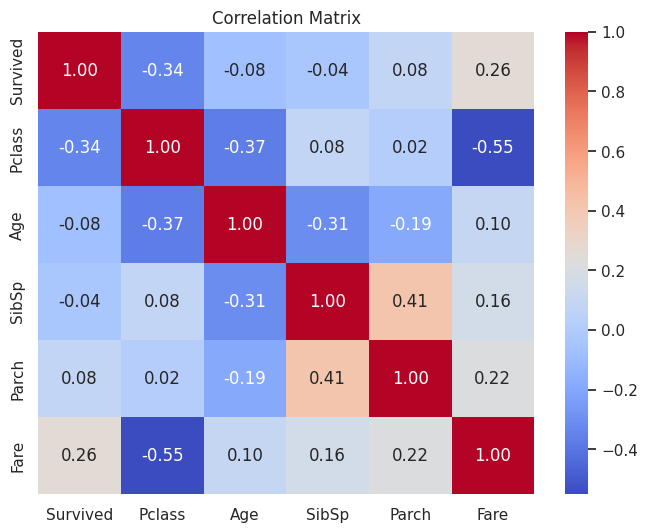

In [15]:
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns.drop('PassengerId')

plt.figure(figsize=(8, 6))
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix')
plt.show()

## 5. Outlier detection

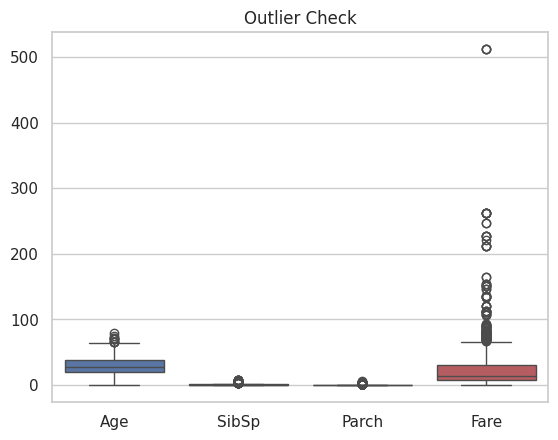

In [16]:
sns.boxplot(data=df[['Age', 'SibSp', 'Parch', 'Fare']])
plt.title('Outlier Check')
plt.show()

`Fare` is strongly right-skewed with extreme values. These will be capped with the IQR rule after the train-test split, using limits learned from the **training data only** to avoid data leakage.

## 6. Feature selection and preparation

In [17]:
# Drop identifier / free-text columns and the mostly-empty Cabin column
df_model = df.drop(columns=['PassengerId', 'Name', 'Ticket', 'Cabin']).copy()

# Feature engineering
df_model['FamilySize'] = df_model['SibSp'] + df_model['Parch'] + 1
df_model['IsAlone'] = (df_model['FamilySize'] == 1).astype(int)

# Only 2 values are missing in Embarked, so fill with the most frequent port
df_model['Embarked'] = df_model['Embarked'].fillna(df_model['Embarked'].mode()[0])

# Encode categorical variables
df_model = pd.get_dummies(df_model, columns=['Sex', 'Embarked'], drop_first=True, dtype=int)
df_model.head()

,Survived,Pclass,Age,SibSp,Parch,Fare,FamilySize,IsAlone,Sex_male,Embarked_Q,Embarked_S
0,0,3,22.0,1,0,7.2500,2,0,1,0,1
1,1,1,38.0,1,0,71.2833,2,0,0,0,0
2,1,3,26.0,0,0,7.9250,1,1,0,0,1
3,1,1,35.0,1,0,53.1000,2,0,0,0,1
4,0,3,35.0,0,0,8.0500,1,1,1,0,1


In [18]:
X = df_model.drop('Survived', axis=1)
y = df_model['Survived']
print(X.columns.tolist())

['Pclass', 'Age', 'SibSp', 'Parch', 'Fare', 'FamilySize', 'IsAlone', 'Sex_male', 'Embarked_Q', 'Embarked_S']


## 7. Train-test split

In [19]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

(712, 10) (179, 10) (712,) (179,)


## 8. Treat outliers (IQR capping, limits from training data)

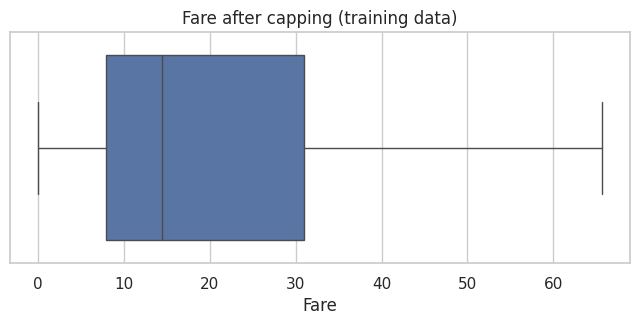

In [20]:
outlier_cols = ['Fare']

for col in outlier_cols:
    Q1 = X_train[col].quantile(0.25)
    Q3 = X_train[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    X_train[col] = X_train[col].clip(lower_bound, upper_bound)
    X_test[col] = X_test[col].clip(lower_bound, upper_bound)

fig, axes = plt.subplots(1, 1, figsize=(8, 3))
sns.boxplot(data=X_train, x='Fare', ax=axes)
axes.set_title('Fare after capping (training data)')
plt.show()

## 9. Median imputation, scaling and model training

In [21]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

model = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),   # fills missing Age
    ('scaler', StandardScaler()),
    ('logreg', LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42))
])
model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('imputer', ...), ('scaler', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"missing_values missing_values: int, float, str, np.nan, None or pandas.NA, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`can be set to either `np.nan` or `pd.NA`.",nan
,"strategy strategy: str or Callable, default='mean'The imputation strategy.- If ""mean"", then replace missing values using the mean along each column. Can only be used with numeric data.- If ""median"", then replace missing values using the median along each column. Can only be used with numeric data.- If ""most_frequent"", then replace missing using the most frequent value along each column. Can be used with strings or numeric data. If there is more than one such value, only the smallest is returned.- If ""constant"", then replace missing values with fill_value. Can be used with strings or numeric data.- If an instance of Callable, then replace missing values using the scalar statistic returned by running the callable over a dense 1d array containing non-missing values of each column... versionadded:: 0.20 strategy=""constant"" for fixed value imputation... versionadded:: 1.5 strategy=callable for custom value imputation.",'median'
,"fill_value fill_value: str or numerical value, default=NoneWhen strategy == ""constant"", `fill_value` is used to replace alloccurrences of missing_values. For string or object data types,`fill_value` must be a string.If `None`, `fill_value` will be 0 when imputing numericaldata and ""missing_value"" for strings or object data types.",None
,"copy copy: bool, default=TrueIf True, a copy of X will be created. If False, imputation willbe done in-place whenever possible. Note that, in the following cases,a new copy will always be made, even if `copy=False`:- If `X` is not an array of floating values;- If `X` is encoded as a CSR matrix;- If `add_indicator=True`.",True
,"add_indicator add_indicator: bool, default=FalseIf True, a :class:`MissingIndicator` transform will stack onto outputof the imputer's transform. This allows a predictive estimatorto account for missingness despite imputation. I

## 10. Evaluation

In [22]:
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, confusion_matrix, classification_report, roc_curve)

y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)
conf_matrix = confusion_matrix(y_test, y_pred)

print('Accuracy :', round(accuracy, 3))
print('Precision:', round(precision, 3))
print('Recall   :', round(recall, 3))
print('F1-score :', round(f1, 3))
print('ROC-AUC  :', round(roc_auc, 3))
print('\nClassification report:\n', classification_report(y_test, y_pred))

Accuracy : 0.788
Precision: 0.707
Recall   : 0.768
F1-score : 0.736
ROC-AUC  : 0.846

Classification report:
               precision    recall  f1-score   support

           0       0.85      0.80      0.82       110
           1       0.71      0.77      0.74        69

    accuracy                           0.79       179
   macro avg       0.78      0.78      0.78       179
weighted avg       0.79      0.79      0.79       179



TN = 88, FP = 22, FN = 16, TP = 53


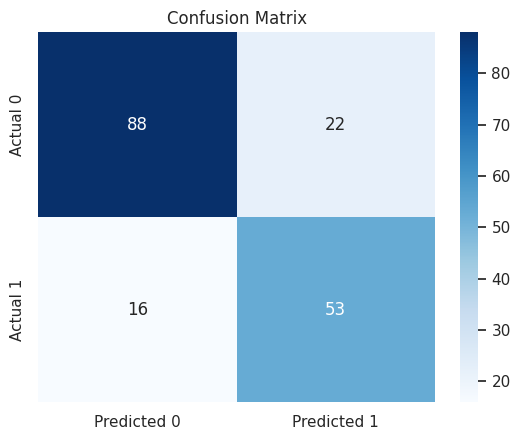

In [23]:
tn, fp, fn, tp = conf_matrix.ravel()
print(f'TN = {tn}, FP = {fp}, FN = {fn}, TP = {tp}')

sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'])
plt.title('Confusion Matrix')
plt.show()

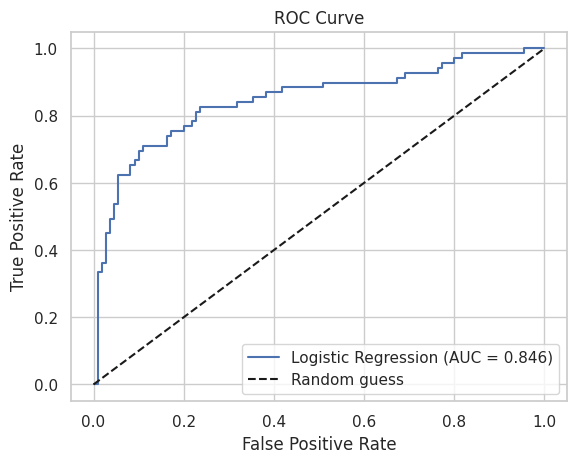

In [24]:
fpr, tpr, _ = roc_curve(y_test, y_prob)
plt.plot(fpr, tpr, label=f'Logistic Regression (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

## 11. Interpret coefficients

,Feature,Coefficient,Odds Ratio
4,Fare,0.351,1.421
8,Embarked_Q,0.089,1.093
3,Parch,-0.081,0.922
9,Embarked_S,-0.129,0.879
6,IsAlone,-0.260,0.771
5,FamilySize,-0.260,0.771
2,SibSp,-0.326,0.722
1,Age,-0.505,0.604
0,Pclass,-0.674,0.510
7,Sex_male,-1.210,0.298


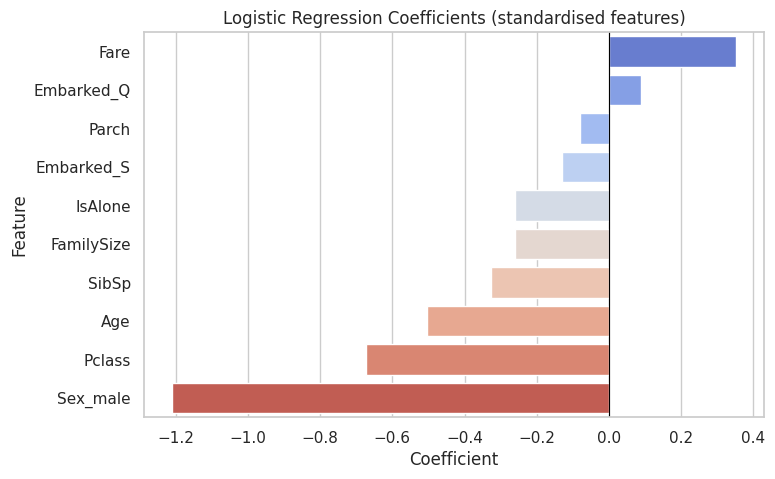

In [25]:
coef_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.named_steps['logreg'].coef_[0]
}).sort_values('Coefficient', ascending=False)
coef_df['Odds Ratio'] = np.exp(coef_df['Coefficient'])
display(coef_df.round(3))

plt.figure(figsize=(8, 5))
sns.barplot(data=coef_df, x='Coefficient', y='Feature', hue='Feature', palette='coolwarm', legend=False)
plt.axvline(0, color='black', lw=0.8)
plt.title('Logistic Regression Coefficients (standardised features)')
plt.show()

In [26]:
# Save the metrics so the PDF report uses the exact same numbers
import json
metrics = {
    'accuracy': round(accuracy, 3), 'precision': round(precision, 3), 'recall': round(recall, 3),
    'f1': round(f1, 3), 'roc_auc': round(roc_auc, 3),
    'tn': int(tn), 'fp': int(fp), 'fn': int(fn), 'tp': int(tp),
    'top_positive': coef_df.iloc[0]['Feature'], 'top_negative': coef_df.iloc[-1]['Feature'],
    'coefficients': {r.Feature: round(r.Coefficient, 3) for r in coef_df.itertuples()}
}
with open('metrics.json', 'w') as f:
    json.dump(metrics, f, indent=2)
metrics

{'accuracy': 0.788,
 'precision': 0.707,
 'recall': 0.768,
 'f1': 0.736,
 'roc_auc': 0.846,
 'tn': 88,
 'fp': 22,
 'fn': 16,
 'tp': 53,
 'top_positive': 'Fare',
 'top_negative': 'Sex_male',
 'coefficients': {'Fare': 0.351,
  'Embarked_Q': 0.089,
  'Parch': -0.081,
  'Embarked_S': -0.129,
  'IsAlone': -0.26,
  'FamilySize': -0.26,
  'SibSp': -0.326,
  'Age': -0.505,
  'Pclass': -0.674,
  'Sex_male': -1.21}}

## 12. Final conclusion
The logistic regression model reached a ROC-AUC of about 0.846 and an accuracy of 0.788 on the held-out test split. It correctly found 53 of the 69 passengers who survived (recall 0.768), with a precision of 0.707, so roughly 7 in 10 predicted survivors actually survived.

Sex was the strongest factor: being male has the largest negative coefficient, followed by a higher passenger class number (lower class) and older age, all of which reduce the chance of survival. Fare has the largest positive coefficient, which fits with first-class passengers being more likely to survive; Fare and Pclass are related, so their effects should not be read in isolation.

**Limitation:** this is a small historical dataset from one event, with missing Age values filled by the median and most Cabin data dropped. The model is suitable for learning classification concepts, not for drawing real-world conclusions.

_(Replace this paragraph with your own words before submitting.)_